# Cuando la moral satura el mensaje

1.621.147 mensajes de Twitter, Reddit y 8chan. Más moral va con más alcance; más moral *concentrada*, con menos. Las dos cosas conviven en los mismos datos, y solo se ven al separarlas.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Saturation of moral language predicts lower content engagement on social media* — Candia, Atari, Kteily y Uzzi, *Nature Human Behaviour* (2 de septiembre de 2026)
**DOI:** [10.1038/s41562-026-02560-y](https://doi.org/10.1038/s41562-026-02560-y)
**Datos:** [repositorio público en OSF](https://osf.io/wzymh/)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-04-saturacion-moral-redes-sociales/notebook.ipynb)

**Video:** [Pendiente]

## De qué van estos datos

El equipo tomó 1.621.147 observaciones de tres plataformas —Twitter (530.104), Reddit (1.048.653) y 8chan (42.390)— repartidas en 13 canales: seis temas de Twitter, cuatro subreddits y tres tablones de 8chan.

A cada texto le midieron dos cosas distintas que es fácil confundir:

- **Carga moral** — cuánta relevancia moral tiene el mensaje en conjunto.
- **Densidad moral** — qué tan concentrado está ese contenido moral, palabra a palabra.

Ambas salen de comparar el texto contra un diccionario moral validado por expertos, convirtiendo cada palabra en una lista de números que captura su significado (*word embeddings*) para medir a qué se parece. Ese método se llama DDR.

Dos advertencias antes de mirar nada. Primera: esto es **observacional** — nadie manipuló nada, se miró lo que ya había pasado. Segunda: el *engagement* **no es la misma variable en las tres redes**. En Twitter son retweets; en Reddit y 8chan, respuestas. Comparamos formas de curva, nunca niveles.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DENSIDAD_PICO_PAPER = 0.30      # Punto de inflexión del modelo ajustado del paper
N_MINIMO_BANDA      = 200       # Bandas con menos posts que esto son ruido
FUENTE = 'Fuente: Candia et al. (2026), Nature Human Behaviour | Datos: OSF osf.io/wzymh'

COLOR_DATOS      = '#2563EB'    # Azul CaM
COLOR_ALERTA     = '#DC2626'    # Rojo
COLOR_SECUNDARIO = '#059669'    # Emerald
COLOR_REFERENCIA = '#D97706'    # Amber
COLOR_CONTEXTO   = '#BBBBBB'    # Gris

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Estilo CaM (local -> fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Descarga automática de los CSV si el notebook corre fuera del repo
ARCHIVOS = ['muestra_por_canal', 'curva_densidad_plataforma',
            'densidad_por_carga_moral', 'aic_penalizacion_vs_difusion',
            'mediacion_ddr', 'comparacion_medidas_morales']
os.makedirs('datos', exist_ok=True)
for nombre in ARCHIVOS:
    destino = f'datos/{nombre}.csv'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(f'{BASE}/papers/2026-09-04-saturacion-moral-redes-sociales/datos/{nombre}.csv', destino)

muestra   = pd.read_csv('datos/muestra_por_canal.csv')
curva     = pd.read_csv('datos/curva_densidad_plataforma.csv')
terciles  = pd.read_csv('datos/densidad_por_carga_moral.csv')
aic       = pd.read_csv('datos/aic_penalizacion_vs_difusion.csv')
mediacion = pd.read_csv('datos/mediacion_ddr.csv')
medidas   = pd.read_csv('datos/comparacion_medidas_morales.csv')

# Los CSV vienen del paquete OSF con la etiqueta de 8chan escrita de tres formas
for df in (muestra, curva, terciles, aic, mediacion, medidas):
    df['plataforma'] = df['plataforma'].replace({'8 Chan': '8chan', '8Chan': '8chan'})

ORDEN = ['Twitter', 'Reddit', '8chan']
UNIDAD = {'Twitter': 'retweets', 'Reddit': 'respuestas', '8chan': 'respuestas'}

print(f'Observaciones en los modelos : {muestra.filas_modelo.sum():,}'.replace(',', '.'))
print(f'Filas brutas antes de excluir: {muestra.filas_brutas.sum():,}'.replace(',', '.'))
print(f'Excluidas por datos faltantes: {muestra.excluidos_por_faltantes.sum():,}'.replace(',', '.'))
print(f'Canales                      : {len(muestra)}')
print()
for p in ORDEN:
    g = muestra[muestra.plataforma == p]
    n = f'{g.filas_modelo.sum():,}'.replace(',', '.')
    print(f'  {p:8s} {n:>9s} observaciones en {len(g)} canales — engagement = {UNIDAD[p]}')

Observaciones en los modelos : 1.621.147
Filas brutas antes de excluir: 1.633.554
Excluidas por datos faltantes: 12.407
Canales                      : 13

  Twitter    530.104 observaciones en 6 canales — engagement = retweets
  Reddit   1.048.653 observaciones en 4 canales — engagement = respuestas
  8chan       42.390 observaciones en 3 canales — engagement = respuestas


## Aquí está.

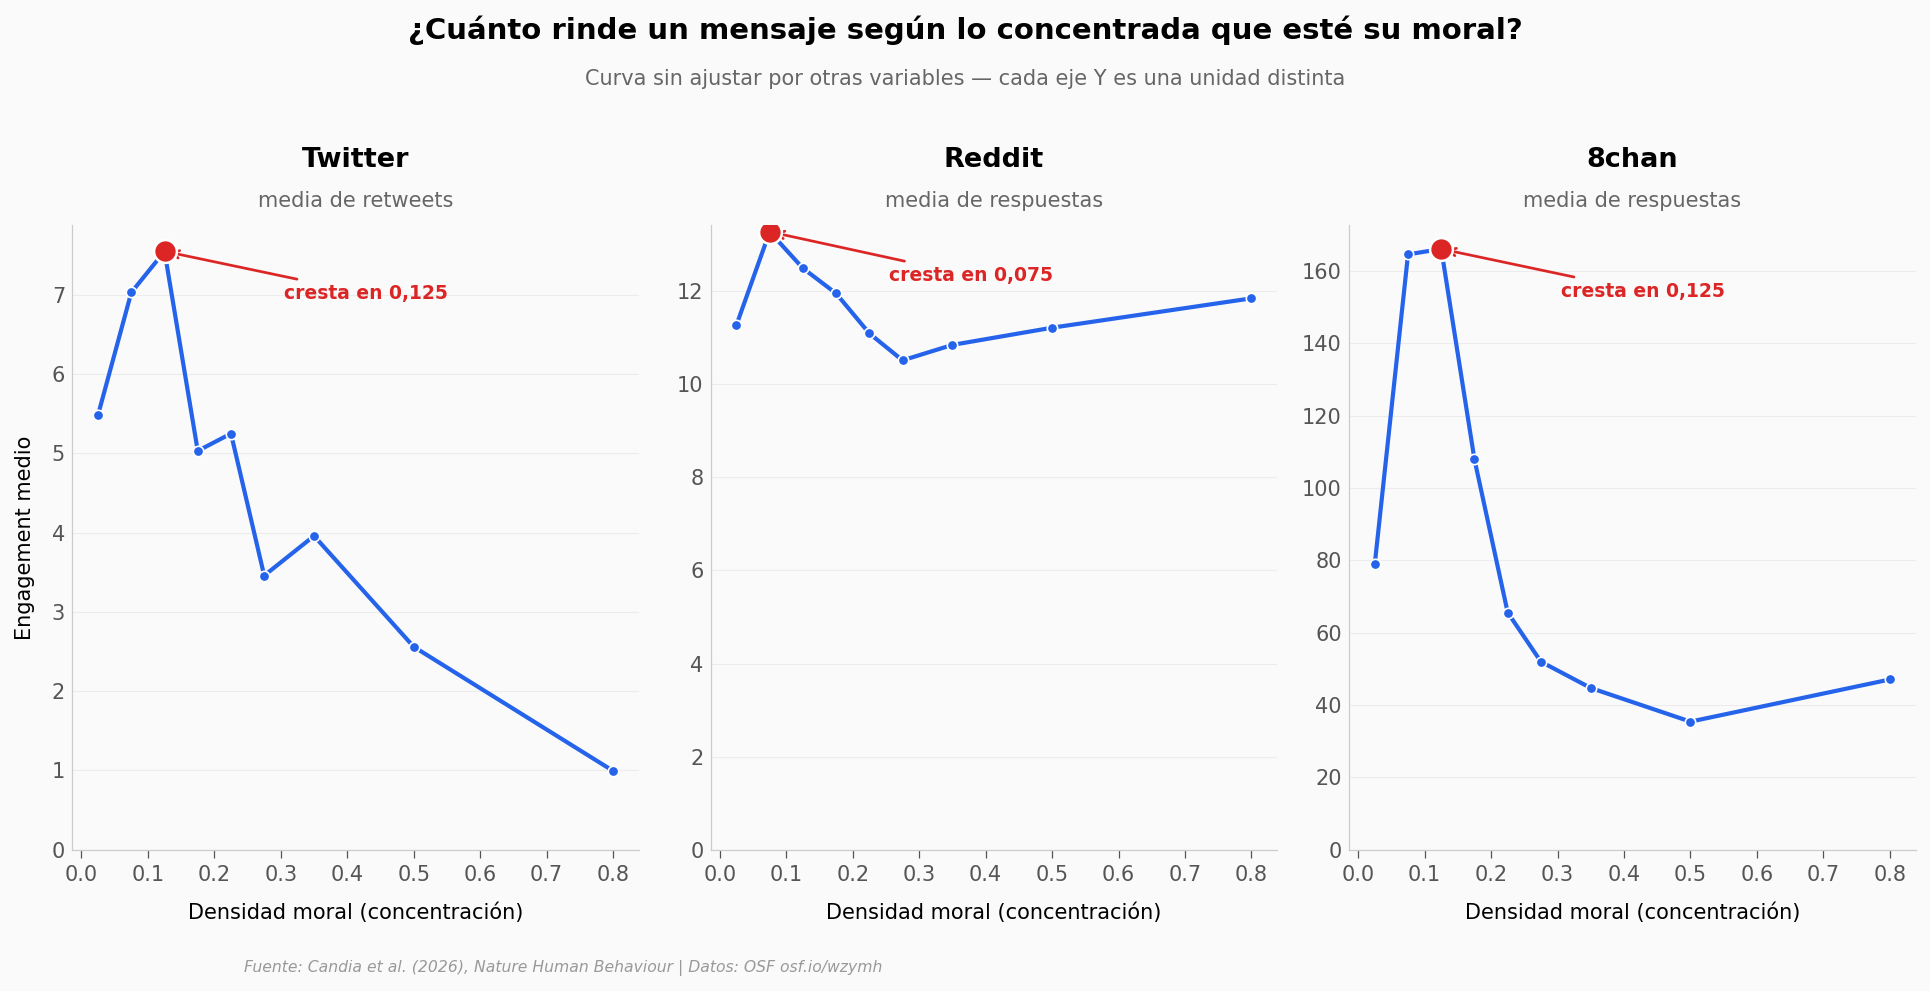

Twitter  cresta en densidad 0.125 con     7.55 retweets    (n = 97.042)
Reddit   cresta en densidad 0.075 con    13.28 respuestas  (n = 227.617)
8chan    cresta en densidad 0.125 con   166.04 respuestas  (n = 13.782)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))

for ax, p in zip(axes, ORDEN):
    g = curva[curva.plataforma == p].sort_values('densidad_moral_centro')
    ax.plot(g.densidad_moral_centro, g.engagement_medio,
            color=COLOR_DATOS, linewidth=2, marker='o', markersize=5,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)

    # Marcar la cresta de la curva cruda
    pico = g.loc[g.engagement_medio.idxmax()]
    ax.scatter([pico.densidad_moral_centro], [pico.engagement_medio],
               color=COLOR_ALERTA, s=120, zorder=6,
               edgecolors='white', linewidths=1.2)
    ax.annotate(f'cresta en {pico.densidad_moral_centro:.3f}'.replace('.', ','),
                xy=(pico.densidad_moral_centro, pico.engagement_medio),
                xytext=(pico.densidad_moral_centro + 0.18, pico.engagement_medio * 0.92),
                fontsize=9, fontweight='bold', color=COLOR_ALERTA,
                arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

    ax.set_title(p, fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, f'media de {UNIDAD[p]}', transform=ax.transAxes,
            fontsize=10, color='#666666', ha='center')
    ax.set_xlabel('Densidad moral (concentración)', fontsize=10)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Engagement medio', fontsize=10)
plt.tight_layout()
fig.suptitle('¿Cuánto rinde un mensaje según lo concentrada que esté su moral?',
             fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.045, 'Curva sin ajustar por otras variables — cada eje Y es una unidad distinta',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_cruda.png', dpi=200, bbox_inches='tight')
plt.show()

for p in ORDEN:
    g = curva[curva.plataforma == p]
    pico = g.loc[g.engagement_medio.idxmax()]
    n_pico = f'{int(pico.n_posts):,}'.replace(',', '.')
    print(f'{p:8s} cresta en densidad {pico.densidad_moral_centro:.3f} '
          f'con {pico.engagement_medio:8.2f} {UNIDAD[p]:11s} (n = {n_pico})')

Las tres suben y luego bajan, pero no con la misma fuerza. La cresta llega temprano —en 0,125 para Twitter y 8chan, en 0,075 para Reddit— y a partir de ahí el rendimiento cae: en 8chan de 166,0 a 35,4 respuestas entre la cresta y la banda 0,40–0,60, y en Twitter de 7,5 a 1,0 retweets. En Reddit la caída es mucho más leve —de 13,3 a 10,5— y la última banda vuelve a subir a 11,8.

Pero esta curva todavía no dice lo que parece decir. Está mezclando dos efectos que van en direcciones opuestas, porque carga y densidad **suben juntas** (correlación de rangos de 0,49 a 0,76 según la plataforma, tal como la reporta el paper — el paquete público de OSF viene agregado por bandas y no permite recalcularla aquí). Un mensaje con la moral muy concentrada suele ser también un mensaje con mucha moral encima, y esos dos rasgos tiran del engagement en sentidos contrarios.

Y hay un detalle más: la cresta de esta curva cruda cae mucho antes que el 0,30 que reporta el paper. No es una contradicción — son dos objetos distintos, y más abajo separamos por qué.

## Separemos los dos efectos

La forma de desenredarlo es mirar la densidad **dentro de** grupos con carga moral parecida. Partimos cada plataforma en tres terciles de carga —baja, media, alta— y dentro de cada uno preguntamos lo mismo: a igual relevancia moral, ¿qué pasa cuando la moral se concentra?

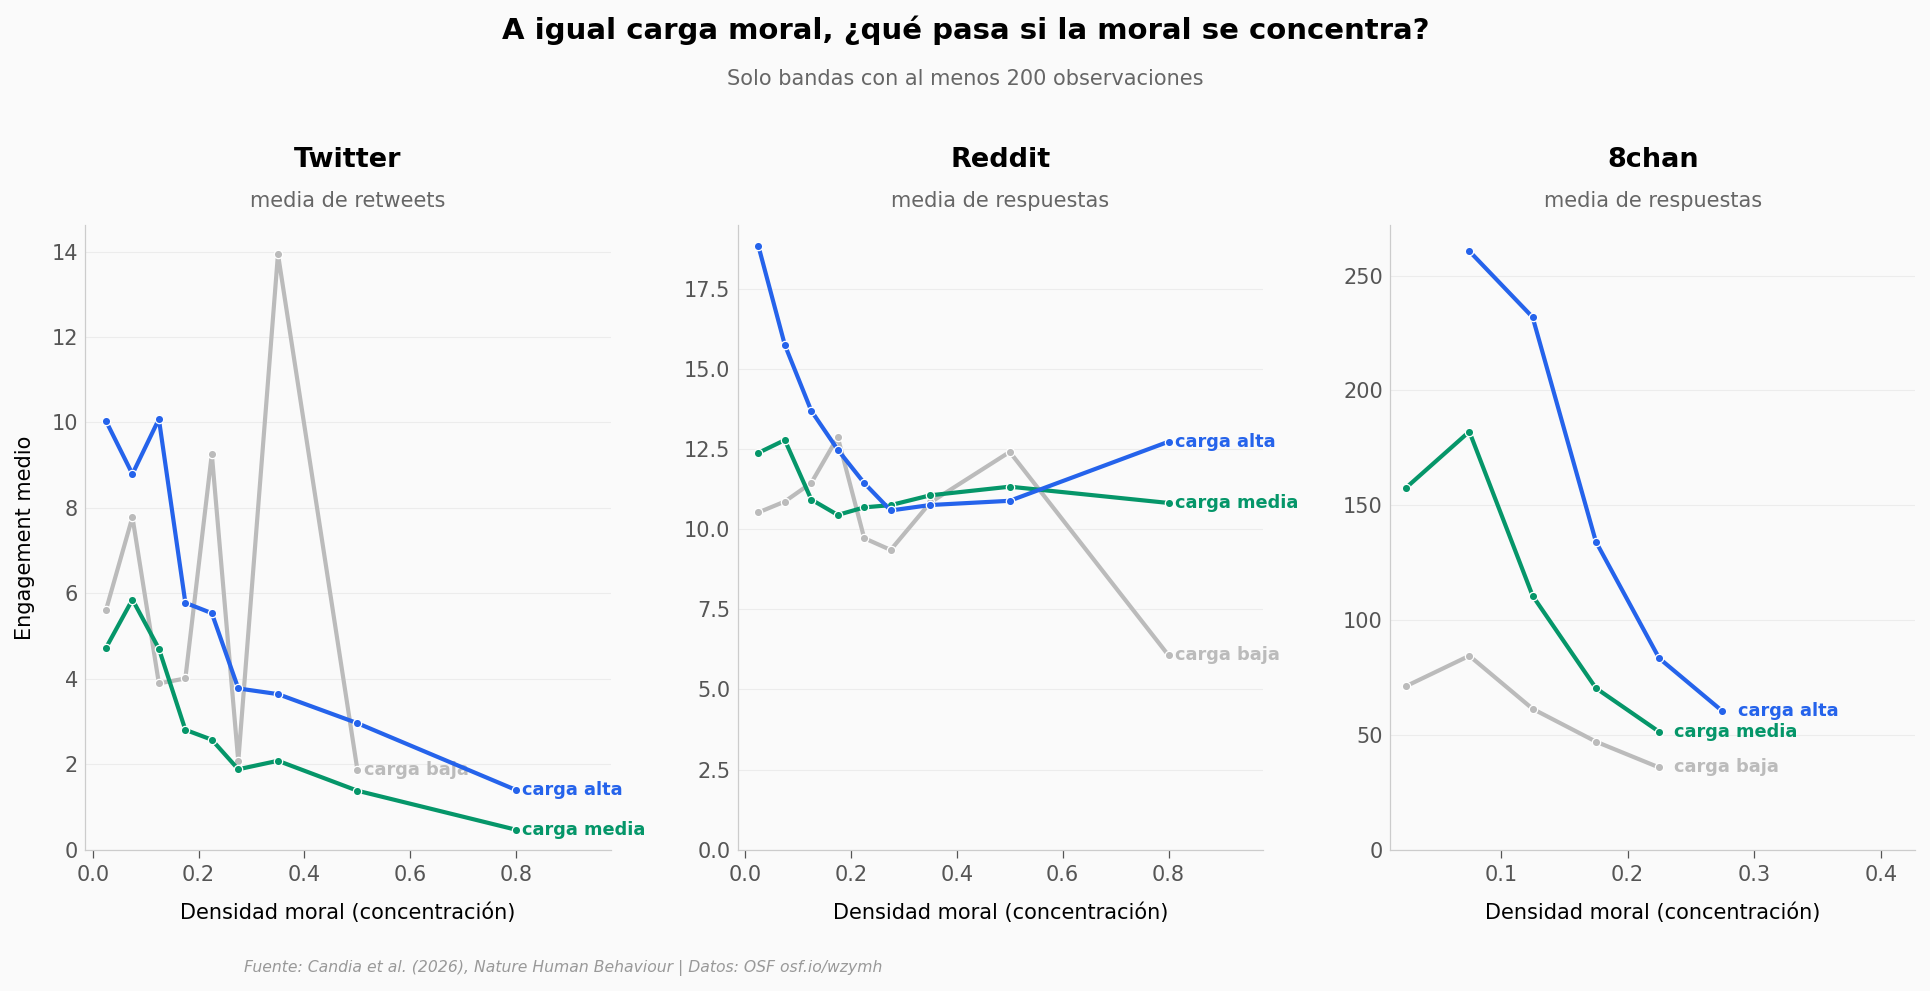

Correlación de Spearman entre densidad moral y engagement, dentro de cada tercil
(Spearman y no Pearson: las distribuciones son muy asimétricas a la derecha)

  Twitter  carga bajo    rho = -0.21   p = 0.6103   bandas = 8
  Twitter  carga medio   rho = -0.97   p = 0.0000   bandas = 9
  Twitter  carga alto    rho = -0.95   p = 0.0001   bandas = 9
  Reddit   carga bajo    rho = -0.28   p = 0.4600   bandas = 9
  Reddit   carga medio   rho = -0.30   p = 0.4328   bandas = 9
  Reddit   carga alto    rho = -0.68   p = 0.0424   bandas = 9
  8chan    carga bajo    rho = -0.90   p = 0.0374   bandas = 5
  8chan    carga medio   rho = -0.90   p = 0.0374   bandas = 5
  8chan    carga alto    rho = -1.00   p = 0.0000   bandas = 5

Combinaciones con correlación negativa: 9 de 9


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
COLOR_TERCIL = {'bajo': COLOR_CONTEXTO, 'medio': COLOR_SECUNDARIO, 'alto': COLOR_DATOS}
ETIQUETA = {'bajo': 'carga baja', 'medio': 'carga media', 'alto': 'carga alta'}

rho_tabla = []
for ax, p in zip(axes, ORDEN):
    for t in ['bajo', 'medio', 'alto']:
        g = terciles[(terciles.plataforma == p) &
                     (terciles.tercil_carga_moral == t) &
                     (terciles.n_posts >= N_MINIMO_BANDA)].sort_values('densidad_moral_centro')
        ax.plot(g.densidad_moral_centro, g.engagement_medio,
                color=COLOR_TERCIL[t], linewidth=2, marker='o', markersize=4,
                markeredgecolor='white', markeredgewidth=0.6, zorder=5)
        # Etiqueta inline al final de cada línea, en vez de caja de leyenda
        ultimo = g.iloc[-1]
        ax.text(ultimo.densidad_moral_centro + 0.012, ultimo.engagement_medio,
                ETIQUETA[t], fontsize=8.5, color=COLOR_TERCIL[t],
                fontweight='bold', va='center')
        # Spearman: los datos son fuertemente asimétricos, no normales (regla del oficio)
        rho, pval = stats.spearmanr(g.densidad_moral_centro, g.engagement_medio)
        rho_tabla.append((p, t, rho, pval, len(g)))

    ax.set_title(p, fontsize=13, fontweight='bold', pad=28)
    ax.text(0.5, 1.03, f'media de {UNIDAD[p]}', transform=ax.transAxes,
            fontsize=10, color='#666666', ha='center')
    ax.set_xlabel('Densidad moral (concentración)', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.set_xlim(right=ax.get_xlim()[1] + 0.14)

axes[0].set_ylabel('Engagement medio', fontsize=10)
plt.tight_layout()
fig.suptitle('A igual carga moral, ¿qué pasa si la moral se concentra?',
             fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.045, f'Solo bandas con al menos {N_MINIMO_BANDA} observaciones',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/terciles_carga.png', dpi=200, bbox_inches='tight')
plt.show()

print('Correlación de Spearman entre densidad moral y engagement, dentro de cada tercil')
print('(Spearman y no Pearson: las distribuciones son muy asimétricas a la derecha)')
print()
for p, t, rho, pval, n in rho_tabla:
    print(f'  {p:8s} carga {t:6s}  rho = {rho:+.2f}   p = {pval:.4f}   bandas = {n}')
negativas = sum(1 for _, _, r, _, _ in rho_tabla if r < 0)
print(f'\nCombinaciones con correlación negativa: {negativas} de {len(rho_tabla)}')

Negativa en las nueve. El caso más nítido es 8chan con carga alta: al pasar la densidad de 0,075 a 0,275, el engagement medio cae de 260,6 a 60,3 respuestas —4,32 veces menos— con una correlación de rangos de −1,00, es decir, cada banda por debajo de la anterior sin una sola excepción. El más flojo es Twitter con carga baja (−0,21).

Miremos también los valores p: con 5 a 9 bandas por línea, 6 de las 9 combinaciones bajan de 0,05 — y ese umbral es generoso, porque con solo 5 bandas (las tres líneas de 8chan) el valor p que calcula `scipy` es una aproximación optimista. Lo robusto aquí es el **signo repetido nueve veces**, no la fuerza de cada correlación por separado. Y en Reddit la caída se concentra en el arranque de la curva: pasada la densidad 0,3, la línea de carga alta vuelve a subir.

Ojo con lo que esto significa y lo que no. Que la relación sea monotónica no dice que concentrar la moral *haga* que te ignoren. Nadie manipuló los textos: se miraron mensajes que ya existían. El propio título del paper usa "predicts", que en estadística quiere decir *anticipa*, no *provoca*.

## Y la otra mitad

Falta comprobar la primera parte del hallazgo: que más carga moral sí va de la mano de más engagement. Los autores comparan además dos explicaciones rivales —una donde la moral penaliza al saturarse y otra donde solo difunde— y miden cuál ajusta mejor los datos de cada canal.

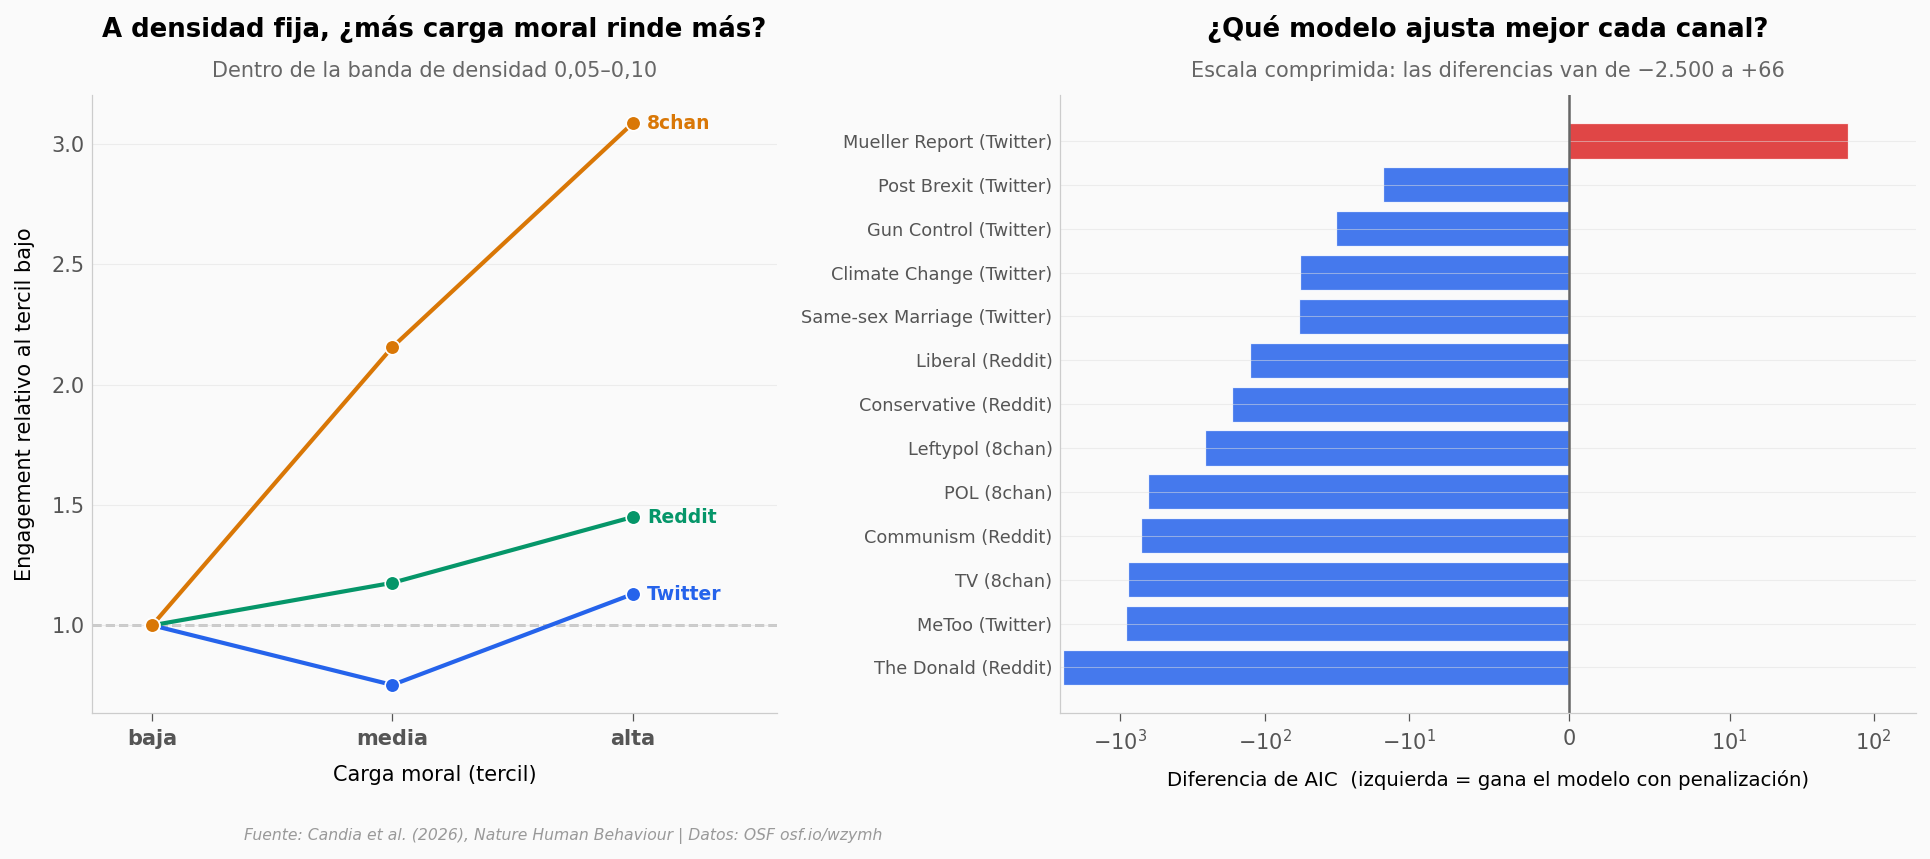

Engagement por tercil de carga moral, dentro de la banda de densidad 0,05-0,10:
  Twitter  7.79 -> 5.86 -> 8.79             alto/bajo = 1.13x   monotónica: NO
  Reddit   10.87 -> 12.79 -> 15.76          alto/bajo = 1.45x   monotónica: sí
  8chan    84.44 -> 182.08 -> 260.63        alto/bajo = 3.09x   monotónica: sí

El modelo con penalización ajusta mejor en 12 de 13 canales.
  Única excepción: Mueller Report (Twitter), diferencia de AIC = +66.19


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                         gridspec_kw={'width_ratios': [1, 1.25]})

# --- Panel izquierdo: efecto de la carga moral a densidad fija (banda 0,05-0,10)
ax = axes[0]
BANDA_FIJA = 0.075
posiciones = {'bajo': 0, 'medio': 1, 'alto': 2}
for p, color in zip(ORDEN, [COLOR_DATOS, COLOR_SECUNDARIO, COLOR_REFERENCIA]):
    g = terciles[(terciles.plataforma == p) &
                 (terciles.densidad_moral_centro == BANDA_FIJA)]
    g = g.set_index('tercil_carga_moral').reindex(['bajo', 'medio', 'alto'])
    # Normalizamos a 1 en el tercil bajo: las tres redes miden cosas distintas
    rel = g.engagement_medio / g.engagement_medio.iloc[0]
    ax.plot(list(posiciones.values()), rel, color=color, linewidth=2,
            marker='o', markersize=7, markeredgecolor='white',
            markeredgewidth=0.8, zorder=5)
    ax.text(2.06, rel.iloc[-1], p, fontsize=9, color=color,
            fontweight='bold', va='center')

ax.axhline(y=1.0, color=COLOR_CONTEXTO, linewidth=1.2, linestyle='--', zorder=1)
ax.set_xticks(list(posiciones.values()))
ax.set_xticklabels(['baja', 'media', 'alta'], fontsize=10, fontweight='bold')
ax.set_xlim(-0.25, 2.6)
ax.set_xlabel('Carga moral (tercil)', fontsize=10)
ax.set_ylabel('Engagement relativo al tercil bajo', fontsize=10)
ax.set_title('A densidad fija, ¿más carga moral rinde más?',
             fontsize=12.5, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Dentro de la banda de densidad 0,05–0,10',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# --- Panel derecho: comparación de modelos por canal (Table 1 del paper)
ax = axes[1]
g = aic.sort_values('diferencia_aic')
colores = [COLOR_DATOS if v < 0 else COLOR_ALERTA for v in g.diferencia_aic]
etiquetas = [f'{c} ({p})' for c, p in zip(g.canal, g.plataforma)]
ax.barh(range(len(g)), g.diferencia_aic, color=colores, alpha=0.85,
        edgecolor='white', linewidth=0.6)
ax.set_yticks(range(len(g)))
ax.set_yticklabels(etiquetas, fontsize=8.5)
ax.axvline(x=0, color='#666666', linewidth=1.2)
ax.set_xscale('symlog', linthresh=10)
ax.set_xlabel('Diferencia de AIC  (izquierda = gana el modelo con penalización)', fontsize=9.5)
ax.set_title('¿Qué modelo ajusta mejor cada canal?',
             fontsize=12.5, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Escala comprimida: las diferencias van de −2.500 a +66',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/carga_y_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

print('Engagement por tercil de carga moral, dentro de la banda de densidad 0,05-0,10:')
for p in ORDEN:
    g = terciles[(terciles.plataforma == p) &
                 (terciles.densidad_moral_centro == BANDA_FIJA)]
    g = g.set_index('tercil_carga_moral').reindex(['bajo', 'medio', 'alto'])
    ratio = g.engagement_medio.iloc[-1] / g.engagement_medio.iloc[0]
    monotona = 'sí' if g.engagement_medio.is_monotonic_increasing else 'NO'
    valores = ' -> '.join(f'{v:.2f}' for v in g.engagement_medio)
    print(f'  {p:8s} {valores:32s} alto/bajo = {ratio:.2f}x   monotónica: {monotona}')

gana = int(aic.gana_penalizacion.sum())
print(f'\nEl modelo con penalización ajusta mejor en {gana} de {len(aic)} canales.')
excepcion = aic[~aic.gana_penalizacion]
for _, r in excepcion.iterrows():
    print(f'  Única excepción: {r.canal} ({r.plataforma}), diferencia de AIC = {r.diferencia_aic:+.2f}')

En Twitter el patrón no es limpio: el tercil medio queda por debajo del bajo, y el salto de baja a alta es de apenas 1,13 veces (n = 25.709 · 63.622 · 31.361 observaciones por tercil). En Reddit sube a 1,45 (n = 47.658 · 111.454 · 68.505) y en 8chan a 3,09 (n = 5.296 · 7.572 · 3.032). La dirección coincide en las tres, la nitidez no. Son medias de bandas ya agregadas: el paquete de OSF no publica la desviación de cada banda, así que aquí no se puede calcular ni un tamaño de efecto ni un intervalo de confianza.

En cuanto a los modelos, el de penalización ajusta mejor en 12 de los 13 canales. La única excepción es el Mueller Report en Twitter. Conviene no inflar esto: una diferencia de AIC compara el ajuste de dos modelos, no es un p-valor ni un tamaño de efecto, y para Post Brexit la ventaja son 15 puntos sobre un AIC de más de 75.000 — una mejora marginal.

## ¿Y qué tan común es un mensaje saturado?

El paper sitúa el punto de inflexión de su modelo ajustado en una densidad de 0,30. Vale la pena preguntarse cuántos mensajes reales llegan siquiera hasta ahí.

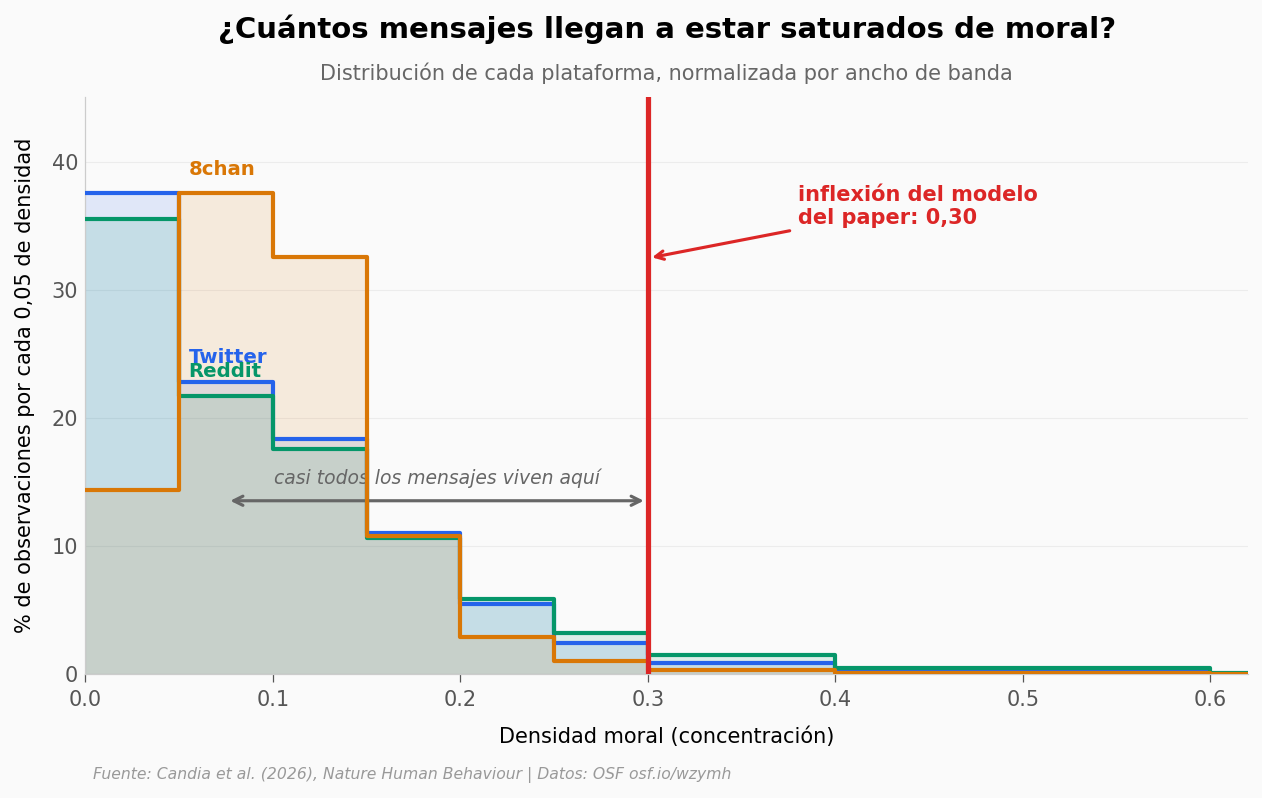

Observaciones con densidad moral igual o mayor a 0.3:
  Twitter   2.42%   (12.844 de 530.104)
  Reddit    5.56%   (58.347 de 1.048.653)
  8chan     0.96%   (405 de 42.390)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Las bandas de densidad NO tienen el mismo ancho (las últimas son más anchas),
# así que normalizamos cada una a un ancho común de 0,05 para poder compararlas.
BORDES = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.60, 1.00]
ANCHO_BASE = 0.05
colores_p = {'Twitter': COLOR_DATOS, 'Reddit': COLOR_SECUNDARIO, '8chan': COLOR_REFERENCIA}

y_max = 0
for p in ORDEN:
    g = curva[curva.plataforma == p].sort_values('densidad_moral_centro')
    total = g.n_posts.sum()
    anchos = np.diff(BORDES)
    pct_normalizado = (g.n_posts.values / total * 100) * (ANCHO_BASE / anchos)
    xs = np.repeat(BORDES, 2)[1:-1]
    ys = np.repeat(pct_normalizado, 2)
    ax.plot(xs, ys, color=colores_p[p], linewidth=2, zorder=5)
    ax.fill_between(xs, ys, color=colores_p[p], alpha=0.12, zorder=2)
    ax.text(0.055, pct_normalizado[1] + 1.5, p, fontsize=9.5,
            color=colores_p[p], fontweight='bold')
    y_max = max(y_max, pct_normalizado.max())

y_max *= 1.20
ax.set_ylim(0, y_max)
ax.set_xlim(0, 0.62)

ax.axvline(x=DENSIDAD_PICO_PAPER, color=COLOR_ALERTA, linewidth=2.5, zorder=6)
ax.annotate('inflexión del modelo\ndel paper: 0,30',
            xy=(DENSIDAD_PICO_PAPER, y_max * 0.72),
            xytext=(DENSIDAD_PICO_PAPER + 0.08, y_max * 0.78),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Flecha bidireccional: dónde está la masa de mensajes frente a dónde está el umbral
ax.annotate('', xy=(DENSIDAD_PICO_PAPER, y_max * 0.30), xytext=(0.075, y_max * 0.30),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((0.075 + DENSIDAD_PICO_PAPER) / 2, y_max * 0.33,
        'casi todos los mensajes viven aquí', fontsize=9,
        color='#666666', ha='center', style='italic')

ax.set_xlabel('Densidad moral (concentración)', fontsize=10)
ax.set_ylabel('% de observaciones por cada 0,05 de densidad', fontsize=10)
ax.set_title('¿Cuántos mensajes llegan a estar saturados de moral?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de cada plataforma, normalizada por ancho de banda',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_densidad.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Observaciones con densidad moral igual o mayor a {DENSIDAD_PICO_PAPER}:')
for p in ORDEN:
    g = curva[curva.plataforma == p]
    total = g.n_posts.sum()
    encima = g[g.densidad_moral_centro >= DENSIDAD_PICO_PAPER].n_posts.sum()
    n_fmt = f'{int(encima):,}'.replace(',', '.')
    t_fmt = f'{int(total):,}'.replace(',', '.')
    print(f'  {p:8s} {encima/total*100:5.2f}%   ({n_fmt} de {t_fmt})')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| A igual carga moral, más densidad va con menos engagement | ✅ | Correlación de Spearman negativa en las 9 combinaciones de plataforma × tercil, de −0,21 (Twitter, carga baja) a −1,00 (8chan, carga alta). Con solo 5–9 bandas por línea, 6 de las 9 alcanzan p < 0,05, y con tan pocas bandas ese valor p es una aproximación optimista — lo que sostiene el hallazgo es el signo repetido en las nueve, no la fuerza individual. Calculado sobre bandas agregadas de al menos 200 observaciones, no sobre observaciones individuales. |
| A igual densidad, más carga moral va con más engagement | ⚠️ | Medido dentro de una sola banda de densidad (0,05–0,10), la dirección se sostiene en las tres redes (8chan 3,09x · Reddit 1,45x · Twitter 1,13x), pero **Twitter no es monotónico**: su tercil medio queda por debajo del bajo. Fuera de esa banda el orden se invierte varias veces (Twitter 0,26x en 0,30–0,40; Reddit 0,88x en 0,40–0,60), y en Twitter la media va montada en la cola —su engagement mediano es 0 en todas las bandas— hasta el punto de que con la media del logaritmo del engagement, la otra columna del mismo CSV, el tercil alto queda por debajo del bajo (0,437 frente a 0,462). En Twitter el efecto es débil. |
| El modelo con penalización ajusta mejor que el de pura difusión | ✅ | Gana en 12 de 13 canales por AIC (Tabla 1 del paper). Única excepción: Mueller Report en Twitter (+66,19). Una diferencia de AIC compara ajuste relativo — no es un p-valor ni un tamaño de efecto, y en Post Brexit son 15 puntos sobre un AIC de más de 75.000. |
| El engagement hace cresta en una densidad de 0,30 | ⚠️ | No es reproducible con estos datos y **no debería serlo**. El 0,30 es el punto de inflexión de un modelo binomial negativo ajustado por carga moral, canal, longitud del post y otras covariables. Nuestra curva es marginal —mezcla ambos efectos— y hace cresta en 0,075 (Reddit) y 0,125 (Twitter y 8chan). Son dos objetos distintos, no un desmentido. El código del paper corre en R (`MASS::glm.nb`); aquí no hay `statsmodels` para replicarlo. |
| Los mensajes saturados de moral son una franja marginal | ✅ | Solo el 2,42% de las observaciones de Twitter, el 5,56% de las de Reddit y el 0,96% de las de 8chan llegan a una densidad de 0,30 o más. La penalización que describe el paper existe, pero casi ningún mensaje real cae en la zona penalizada. |
| Medir "cuánta moral hay en un texto" es un problema resuelto | ❌ | Las cuatro medidas del propio chequeo de los autores coinciden poco: de 0,71 (diccionario ~ DDR-Word2Vec en 8chan; n = 1.975, p < 0,001) a −0,11 (diccionario ~ DDR-transformer en Reddit; n = 2.000, p < 0,001). El resultado depende de qué medida se elija. Es un límite del campo que los autores publican, no un fallo que les encontramos. |

> **Limitaciones**
>
> - **Es observacional.** No hay manipulación ni asignación aleatoria. Nada aquí soporta "concentrar la moral hace que te ignoren".
> - **El engagement no es la misma variable entre plataformas:** retweets en Twitter, respuestas en Reddit y 8chan. Las medias (6,1 · 12,0 · 141,5) no se comparan entre sí — solo las formas de curva.
> - **La unidad de 8chan no es un post:** es un agregado de tablón-día-tema que junta varios hilos (mediana de 2). Ese 2,6% de la muestra no son mensajes individuales.
> - **Carga y densidad están correlacionadas** (Spearman 0,49–0,76). El hallazgo solo existe al separarlas.
> - **Confusión con la longitud:** la densidad extrema aparece sobre todo en textos muy cortos. El paper controla la longitud del post; nuestra curva cruda no, así que parte de la caída puede ser un efecto del mensaje de tres palabras.
> - **Un solo canal domina:** The_Donald aporta 854.936 observaciones, el 52,7% de toda la muestra. Cualquier lectura "global" está inclinada hacia un subreddit político estadounidense ya cerrado.
> - **Son plataformas y momentos concretos:** Reddit viene del archivo público Pushshift recolectado en 2020 y 8chan cubre de febrero de 2016 a agosto de 2019. No son "las redes sociales".
> - **No se puede leer ni un solo mensaje:** el paquete de OSF publica variables derivadas y excluye a propósito el texto, los identificadores y las URL para no permitir re-identificar usuarios.
> - **El cuerpo del paper está tras muro de pago:** verificamos contra el resumen público y contra los datos de OSF.

## Ahora tú

1. **¿Aguanta el hallazgo si subes el listón de ruido?** En la configuración de arriba, `N_MINIMO_BANDA` está en 200. Súbelo a 1.000 y vuelve a correr la celda de terciles: ¿siguen saliendo negativas las nueve correlaciones, o se caen las bandas que sostenían a 8chan?

2. **¿Y si el efecto fuera longitud disfrazada?** La columna `palabras_mediana` de `curva` guarda la longitud típica de cada banda. Grafícala contra `densidad_moral_centro` — si los mensajes de densidad alta son también los más cortos, parte de la caída podría ser otra historia. Pista: `curva.plot(x='densidad_moral_centro', y='palabras_mediana')` por plataforma.

3. **¿El mediador cuenta la misma historia en las tres redes?** El DataFrame `mediacion` trae la Tabla 2 del paper, con la carga cognitiva del texto como intermediario. Filtra `tipo_modelo == 'Outcome model'` y compara el coeficiente del mediador entre plataformas. ¿Coincide el signo?

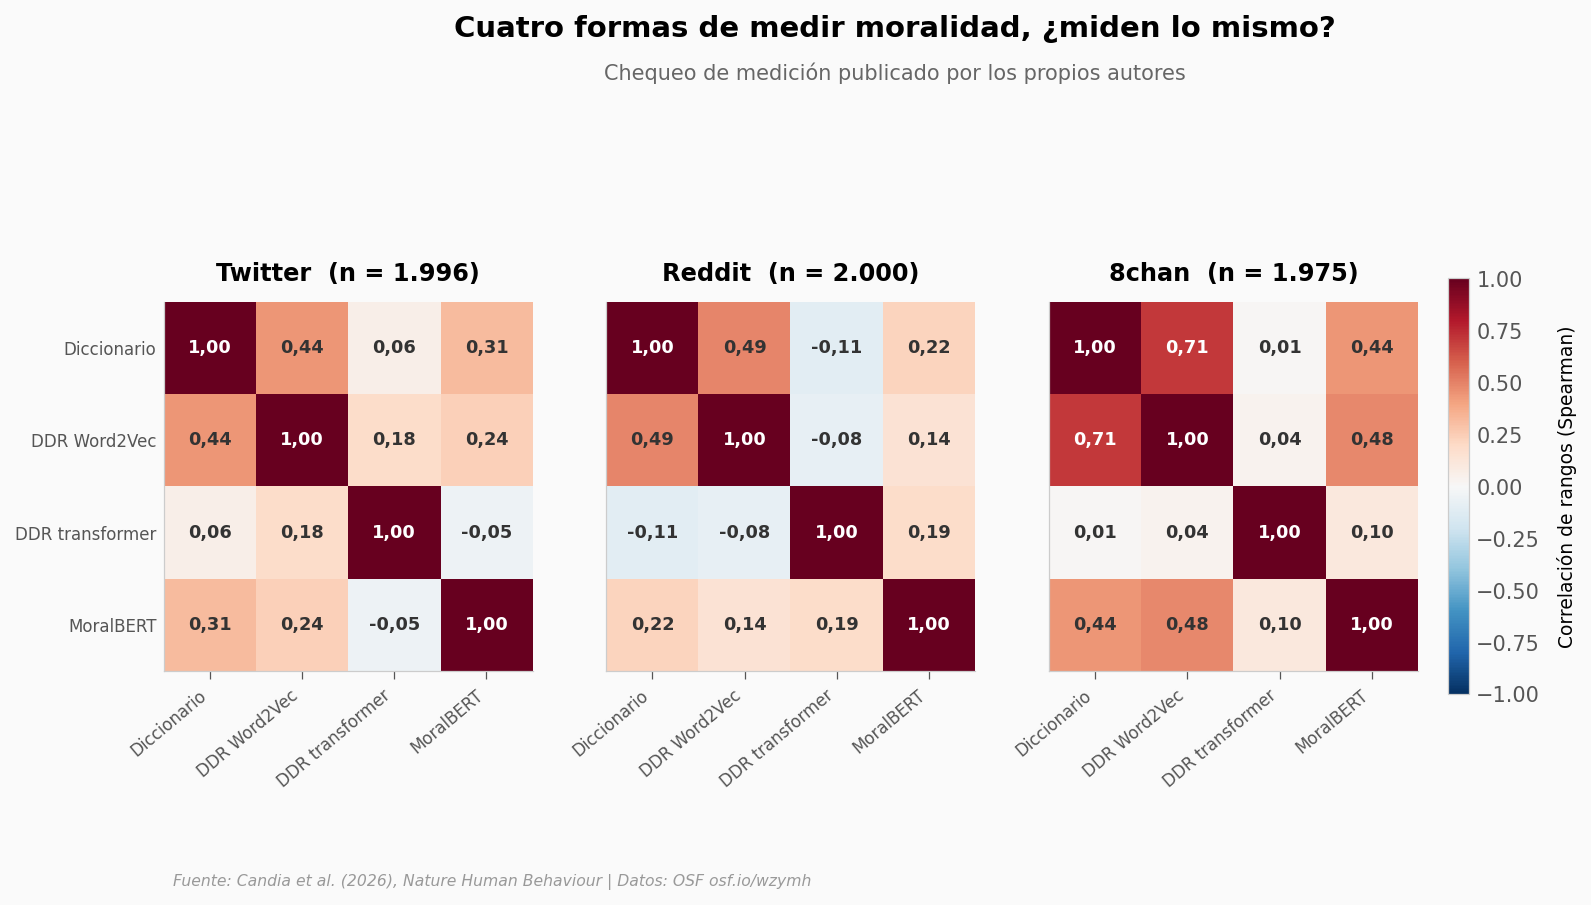

Correlación de rangos entre pares de medidas:
  Twitter  más alta: Diccionario ~ DDR Word2Vec = +0.44   |   más baja: DDR transformer ~ MoralBERT = -0.05
  Reddit   más alta: Diccionario ~ DDR Word2Vec = +0.49   |   más baja: Diccionario ~ DDR transformer = -0.11
  8chan    más alta: Diccionario ~ DDR Word2Vec = +0.71   |   más baja: Diccionario ~ DDR transformer = +0.01


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Coinciden las cuatro formas de medir "cuánta moral hay en un texto"?
# Los autores puntuaron submuestras de unos 2.000 mensajes por plataforma con
# cuatro métodos distintos. Si midieran lo mismo, deberían correlacionar alto.

METODOS = ['diccionario_log', 'ddr_word2vec', 'ddr_transformer', 'moralbert_max']
NOMBRES = ['Diccionario', 'DDR Word2Vec', 'DDR transformer', 'MoralBERT']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
for ax, p in zip(axes, ORDEN):
    g = medidas[medidas.plataforma == p]
    # Spearman por defecto: ninguna de las cuatro medidas es normal (regla del oficio)
    corr = g[METODOS].corr(method='spearman')
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(NOMBRES, fontsize=8, rotation=40, ha='right')
    ax.set_yticklabels(NOMBRES if p == 'Twitter' else [''] * 4, fontsize=8)
    for i in range(4):
        for j in range(4):
            v = corr.iloc[i, j]
            ax.text(j, i, f'{v:.2f}'.replace('.', ','), ha='center', va='center',
                    fontsize=8.5, fontweight='bold',
                    color='white' if abs(v) > 0.55 else '#333333')
    n_fmt = f'{len(g):,}'.replace(',', '.')
    ax.set_title(f'{p}  (n = {n_fmt})', fontsize=11.5, fontweight='bold', pad=10)
    ax.grid(False)

cbar = fig.colorbar(im, ax=axes, shrink=0.75, pad=0.02)
cbar.set_label('Correlación de rangos (Spearman)', fontsize=9)
fig.suptitle('Cuatro formas de medir moralidad, ¿miden lo mismo?',
             fontsize=14, fontweight='bold', y=1.15)
fig.text(0.5, 1.06, 'Chequeo de medición publicado por los propios autores',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/acuerdo_medidas.png', dpi=200, bbox_inches='tight')
plt.show()

print('Correlación de rangos entre pares de medidas:')
for p in ORDEN:
    g = medidas[medidas.plataforma == p]
    corr = g[METODOS].corr(method='spearman')
    pares = [(NOMBRES[i], NOMBRES[j], corr.iloc[i, j])
             for i in range(4) for j in range(i + 1, 4)]
    menor = min(pares, key=lambda x: x[2])
    mayor = max(pares, key=lambda x: x[2])
    print(f'  {p:8s} más alta: {mayor[0]} ~ {mayor[1]} = {mayor[2]:+.2f}   |   '
          f'más baja: {menor[0]} ~ {menor[1]} = {menor[2]:+.2f}')

## Fuentes

**Paper**: [Saturation of moral language predicts lower content engagement on social media](https://doi.org/10.1038/s41562-026-02560-y)  
*Nature Human Behaviour, 2026-09-02 · muro de pago*

**Dataset canónico**: [Saturation of moral language predicts lower content engagement on social media — public replication repository](https://osf.io/wzymh/)  
*Open Science Framework, 2026-08-20 — paquete público de replicación; los CSV de este notebook se derivan de él*

**Referencias citadas**: [word2vec — GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/) · [MoralBERT — clasificadores de Moral Foundations Theory (vjosap/moralBERT-predict-*)](https://huggingface.co/vjosap/moralBERT-predict-care-in-text)

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [El Lab](https://cienciaamordiscos.com) — Ciencia a Mordiscos.
Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).
Los datos originales son públicos bajo los términos de su repositorio en OSF.*